# Gold fcc111 infinite slab

> Willem de Kleijne | March 17, 2026  
>
> Sample: Gold fcc111    

In [6]:
import abtem
import numpy as np
import matplotlib.pyplot as plt

## Gold Unitcell


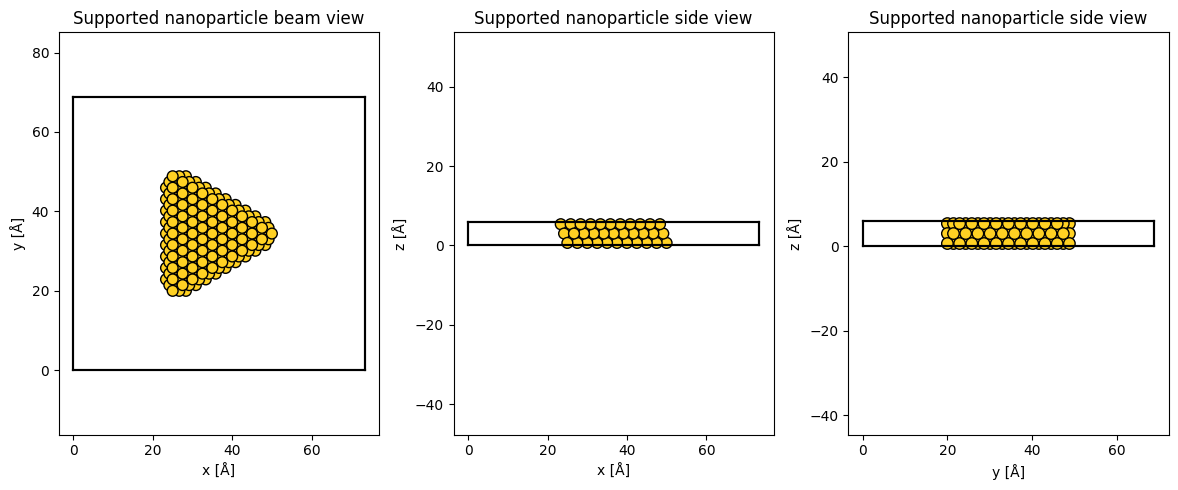

In [38]:
from ase.cluster import FaceCenteredCubic

surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1)]
layers = [15, 11, 5]
lc = 4.08

nanoparticle = FaceCenteredCubic("Au", surfaces, layers, latticeconstant=lc)

rotated_nanoparticle = nanoparticle.copy()

rotated_nanoparticle.rotate(45, "x")

y_angle = np.degrees(np.arctan(1 / np.sqrt(2)))

rotated_nanoparticle.rotate(y_angle, "y")

#| label: app:unit_cell_projections

centered_nanoparticle = rotated_nanoparticle.copy()

centered_nanoparticle.center(vacuum=0)

cut_nanoparticle = centered_nanoparticle.copy()

cut_nanoparticle.cell[2,2] = 6


# mask = cut_nanoparticle.positions[:, 2] < 20

# # # deletion *requires* providing the indices, i.e. boolean indexing does not work
# del cut_nanoparticle[np.where(mask)[0]]

# mask = cut_nanoparticle.positions[:, 1] < 20

# deletion *requires* providing the indices, i.e. boolean indexing does not work
# del cut_nanoparticle[np.where(mask)[0]]
# cut_nanoparticle.center()

mask = cut_nanoparticle.positions[:, 2] > 6
del cut_nanoparticle[np.where(mask)[0]]

cut_nanoparticle_2 = cut_nanoparticle.copy()
cut_nanoparticle_2.rotate(25, 'z')

# set vacuum in x and y to 20 but not in z, so that the nanoparticle is centered in the box
# Then manually expand the cell in x and y only
cell = cut_nanoparticle.get_cell().copy()
cell[0, 0] += 2 * 20  # 20 Å vacuum on each side in x
cell[1, 1] += 2 * 20  # 20 Å vacuum on each side in y
# leave cell[2, 2] untouched (only 0.1 Å padding, effectively none)
cut_nanoparticle.set_cell(cell, scale_atoms=False)

# Re-center so atoms sit in the middle of the new cell
cut_nanoparticle.center()




fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    cut_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();



## Potential

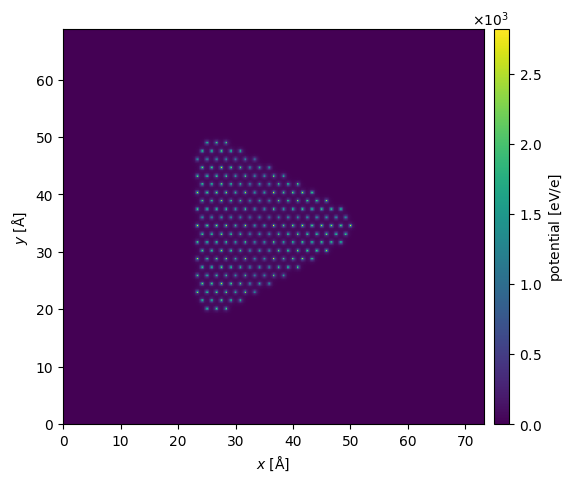

In [39]:
potential = abtem.Potential(
    cut_nanoparticle,
    gpts=(512,512),         # to ensure that the size of diffraction pattern is 512x512
    slice_thickness= lc/8,
    device='cpu',
).build(
    lazy=False
)

potential.show(
    cbar=True
);

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

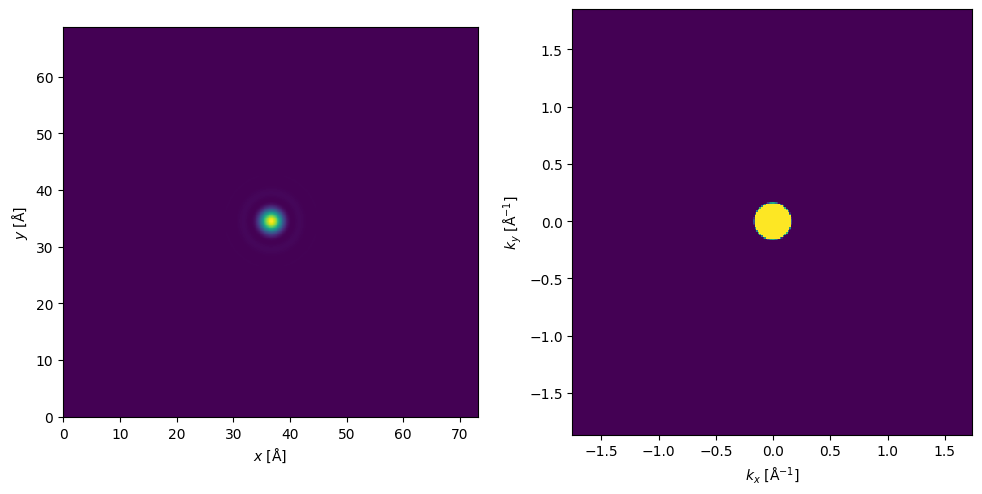

In [40]:
energy = 10e3 # eV
semiangle_cutoff = 20 # mrad


aberrations = {
    "C10":0,
}

probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

fig, axs = plt.subplots(1,2,figsize=(10,5))
probes.show(ax=axs[0])
probes.build().diffraction_patterns(max_angle=None).crop(gpts=(256,256)).show(ax=axs[1])
fig.tight_layout()

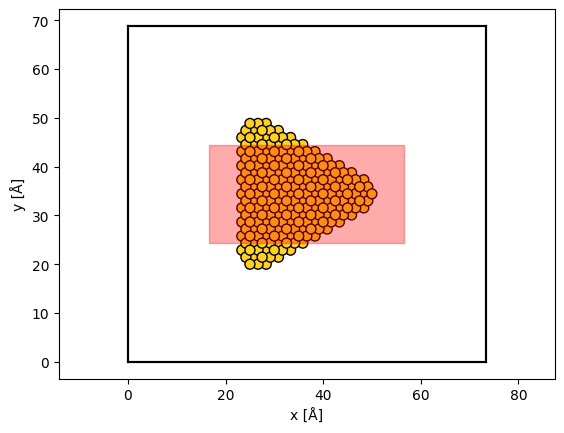

In [41]:
import ase.build

pos = cut_nanoparticle.positions

x_extent = (pos[:, 0].max() + pos[:, 0].min()) / 2
y_extent = (pos[:, 1].max() + pos[:, 1].min()) / 2
gpt_x, gpt_y = 96+1, 48+1
grid_scan = abtem.GridScan(
    start = (x_extent-20, y_extent-10),
    end = (x_extent+20, y_extent+10),
    gpts=(gpt_x, gpt_y),
    endpoint=True
)

fig,ax = plt.subplots()
abtem.show_atoms(cut_nanoparticle,ax=ax)
grid_scan.add_to_plot(ax)

detector = abtem.PixelatedDetector(
    max_angle=None
)

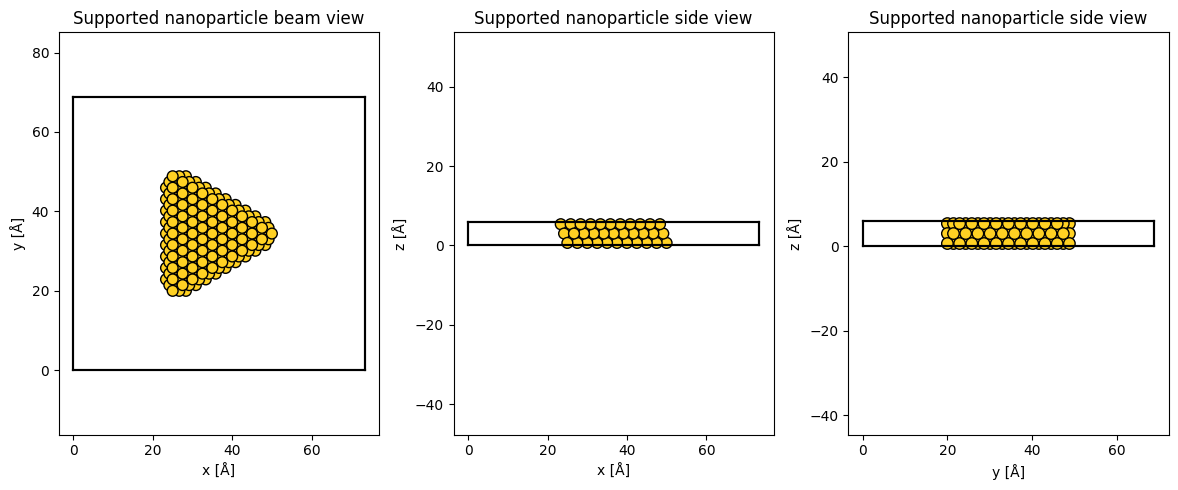

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    cut_nanoparticle ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    cut_nanoparticle ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    cut_nanoparticle ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

In [43]:
measurement = probes.scan(
    potential,
    grid_scan,
    detector,
).compute(
)
dose = 1e7
measurement_noisy = measurement.crop(gpts=(256,256)).poisson_noise(dose)

tasks:   0%|          | 0/93 [00:00<?, ?it/s]

In [44]:
measurement.sampling

(0.013640134420179459, 0.014524337390043848)

In [45]:
dataset_noisy = measurement_noisy.to_quantem()
dataset_noisy

Dataset(shape=(97, 49, 256, 256), dtype=float32, name='DiffractionPatterns')
  sampling: [0.41666667 0.41666667 0.01364013 0.01452434]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

In [46]:
dataset_noisy.save(f"/home/wdekleijne/git-repos/willem-playground/data/triangular_nanoparticle_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_{dose:.0e}-dose_gpts_{gpt_x}_{gpt_y}_3_layer_256x256.zip",mode='o')